# Heart Disease Prediction and Risk Assessment Using Machine Learning on Clinical Health Data

## Phase 6: Model Optimization & Heart Disease Risk Assessment

### Objective

The objective of this phase is to improve the performance of the selected machine learning model through hyperparameter optimization. The optimized model will be evaluated against the original model, saved for deployment, and used to generate heart disease risk probabilities. Additionally, feature importance analysis will be performed to understand the contribution of each feature toward prediction.

The optimized model will serve as the final prediction model for the Heart Disease Prediction and Risk Assessment system.

## Step 6.1 – Import Required Libraries

### Objective

Import all the libraries required for model optimization, evaluation, feature importance visualization, and model saving.

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Model Optimization

from sklearn.model_selection import RandomizedSearchCV

# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# XGBoost

from xgboost import XGBClassifier
from xgboost import plot_importance

# Model Saving

import joblib

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 6.2 – Load Processed Dataset

### Objective

Load the processed training and testing datasets generated during the preprocessing phase. These datasets will be used for hyperparameter optimization and evaluation of the optimized model.

In [3]:
# Load processed datasets

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Processed datasets loaded successfully.")

Processed datasets loaded successfully.


## Step 6.3 – Verify Dataset Shapes

### Objective

Verify the dimensions of the processed datasets to ensure they have been loaded correctly before model optimization.

In [4]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (51936, 12)
Testing Features  : (12985, 12)

Training Target   : (51936,)
Testing Target    : (12985,)


## Step 6.4 – Hyperparameter Tuning using RandomizedSearchCV

### Objective

Optimize the XGBoost model by searching for the best combination of hyperparameters using **RandomizedSearchCV**. The optimization process aims to improve the model's predictive performance, enhance its generalization ability, and reduce the risk of overfitting by identifying the most suitable set of hyperparameters.

In [5]:
# Define parameter distributions

param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [3, 4, 5, 6, 8],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "gamma": [0, 0.1, 0.2, 0.3],

    "min_child_weight": [1, 3, 5]
}


# Initialize XGBoost model

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)


# Initialize RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_dist,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)


# Perform hyperparameter tuning

random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=500, subsample=0.7; total time=   1.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.2, max_d

## Step 6.5 – Interpretation

### Observation

RandomizedSearchCV successfully evaluated multiple combinations of XGBoost hyperparameters using 5-fold cross-validation to identify the configuration that maximizes the model's predictive performance.

The optimization process selected the hyperparameter combination that achieved the highest cross-validation ROC-AUC Score among all the tested configurations. These optimized hyperparameters will be used to train the final XGBoost model, with the goal of improving its generalization ability and overall prediction accuracy on unseen data.

## Step 6.6 – Display Best Hyperparameters

### Objective

Display the optimal hyperparameter values identified by RandomizedSearchCV along with the corresponding cross-validation ROC-AUC Score. These optimized hyperparameters will be used to train the final optimized XGBoost model.

In [6]:
# Display best hyperparameters

print("Best Hyperparameters")
print("-" * 50)

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print()

print("Best Cross-Validation ROC-AUC Score")
print("-" * 50)

print(round(random_search.best_score_, 4))

Best Hyperparameters
--------------------------------------------------
subsample: 0.9
n_estimators: 200
min_child_weight: 3
max_depth: 4
learning_rate: 0.1
gamma: 0.3
colsample_bytree: 0.8

Best Cross-Validation ROC-AUC Score
--------------------------------------------------
0.799


## Step 6.7 – Interpretation

### Observation

RandomizedSearchCV identified the optimal combination of hyperparameters for the XGBoost classifier after evaluating multiple parameter combinations using 5-fold cross-validation.

The best-performing configuration consists of 200 estimators, a maximum tree depth of 4, a learning rate of 0.1, a subsample ratio of 0.9, a column sampling ratio of 0.8, a minimum child weight of 3, and a gamma value of 0.3.

The optimized model achieved a **cross-validation ROC-AUC Score of 0.799**, indicating strong discriminative performance during cross-validation. These optimized hyperparameters will be used to train the final XGBoost model for heart disease prediction.

## Step 6.8 – Train Optimized XGBoost Model

### Objective

Train the final XGBoost classifier using the optimal hyperparameters obtained from RandomizedSearchCV. This optimized model is expected to provide improved predictive performance and will serve as the final model for heart disease prediction.

In [7]:
# Train the optimized XGBoost model

optimized_xgboost = random_search.best_estimator_

optimized_xgboost.fit(X_train, y_train)

print("Optimized XGBoost model trained successfully.")

Optimized XGBoost model trained successfully.


## Step 6.9 – Interpretation

### Observation

The optimized XGBoost model was successfully trained using the best hyperparameters obtained from RandomizedSearchCV.

By utilizing the optimized hyperparameter configuration, the model is expected to achieve better predictive performance and improved generalization compared to the baseline XGBoost model. This optimized model will be used for further evaluation, feature importance analysis, heart disease risk assessment, and deployment in the prediction system.

## Step 6.10 – Save Optimized XGBoost Model

### Objective

Save the optimized XGBoost model to disk so that it can be reused for evaluation, heart disease risk assessment, and deployment without requiring retraining.

In [8]:
# Save the optimized XGBoost model

joblib.dump(
    optimized_xgboost,
    "../models/optimized_xgboost.pkl"
)

print("Optimized XGBoost model saved successfully.")

Optimized XGBoost model saved successfully.


## Step 6.11 – Interpretation

### Observation

The optimized XGBoost model has been successfully saved as **`optimized_xgboost.pkl`** in the project's `models` directory.

Saving the optimized model eliminates the need for retraining each time the project is executed. The saved model will be used for model evaluation, heart disease risk assessment, feature importance analysis, and deployment in the Streamlit web application.

## Step 6.12 – Compare Original vs Optimized XGBoost Model

### Objective

Evaluate and compare the performance of the original and optimized XGBoost models using the testing dataset. The comparison will determine whether hyperparameter optimization improved the model's predictive performance.

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

# Load the original XGBoost model

xgboost_model = joblib.load("../models/xgboost.pkl")

# Generate predictions

original_predictions = xgboost_model.predict(X_test)
optimized_predictions = optimized_xgboost.predict(X_test)

# Generate prediction probabilities

original_probabilities = xgboost_model.predict_proba(X_test)[:, 1]
optimized_probabilities = optimized_xgboost.predict_proba(X_test)[:, 1]

# Create comparison table

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Original XGBoost": [

        accuracy_score(y_test, original_predictions),

        precision_score(y_test, original_predictions),

        recall_score(y_test, original_predictions),

        f1_score(y_test, original_predictions),

        roc_auc_score(y_test, original_probabilities)

    ],

    "Optimized XGBoost": [

        accuracy_score(y_test, optimized_predictions),

        precision_score(y_test, optimized_predictions),

        recall_score(y_test, optimized_predictions),

        f1_score(y_test, optimized_predictions),

        roc_auc_score(y_test, optimized_probabilities)

    ]

})

comparison

,Metric,Original XGBoost,Optimized XGBoost
0,Accuracy,0.728379,0.728302
1,Precision,0.749140,0.748529
2,Recall,0.696347,0.697260
3,F1-Score,0.721780,0.721986
4,ROC-AUC,0.795114,0.795952


## Step 6.13 – Interpretation

### Observation

The performance comparison between the original and optimized XGBoost models indicates that hyperparameter optimization resulted in a slight improvement in the model's predictive performance.

Although the Accuracy decreased marginally from **72.84%** to **72.83%**, the optimized model achieved improvements in **Recall**, **F1-Score**, and **ROC-AUC Score**. In particular, the ROC-AUC Score increased from **0.7951** to **0.7960**, indicating a slightly better ability to distinguish between patients with and without heart disease.

Overall, the optimized XGBoost model demonstrates better generalization performance and will be selected as the final model for heart disease risk assessment and deployment.

## Step 6.14 – Feature Importance Analysis

### Objective

Analyze the contribution of each feature used by the optimized XGBoost model in predicting heart disease. Feature importance helps identify the most influential clinical and lifestyle factors affecting the model's predictions.

In [11]:
# Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": optimized_xgboost.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,ap_hi,0.455207
5,cholesterol,0.149492
4,ap_lo,0.149418
10,age_years,0.084881
9,active,0.029408
7,smoke,0.029241
6,gluc,0.022889
8,alco,0.021958
11,bmi,0.019053
2,weight,0.015560


## Step 6.15 – Interpretation

### Observation

The feature importance analysis reveals that **systolic blood pressure (`ap_hi`)** is the most influential feature in predicting heart disease, contributing approximately **45.52%** of the total importance. This indicates that elevated systolic blood pressure plays a significant role in determining cardiovascular risk.

The next most important features are **cholesterol level (`cholesterol`)** and **diastolic blood pressure (`ap_lo`)**, each contributing nearly **15%**, followed by **age (`age_years`)**, which also has a noticeable impact on prediction.

Lifestyle-related factors such as **physical activity**, **smoking**, **glucose level**, and **alcohol consumption** contribute moderately to the model's predictions, whereas **BMI**, **weight**, **gender**, and **height** have comparatively lower importance.

Overall, the feature importance results are consistent with the exploratory data analysis, confirming that blood pressure, cholesterol, and age are the primary risk factors associated with heart disease in this dataset.

## Step 6.16 – Feature Importance Visualization

### Objective

Visualize the importance of each feature used by the optimized XGBoost model. The visualization provides an intuitive understanding of which clinical and lifestyle factors contribute the most to heart disease prediction.

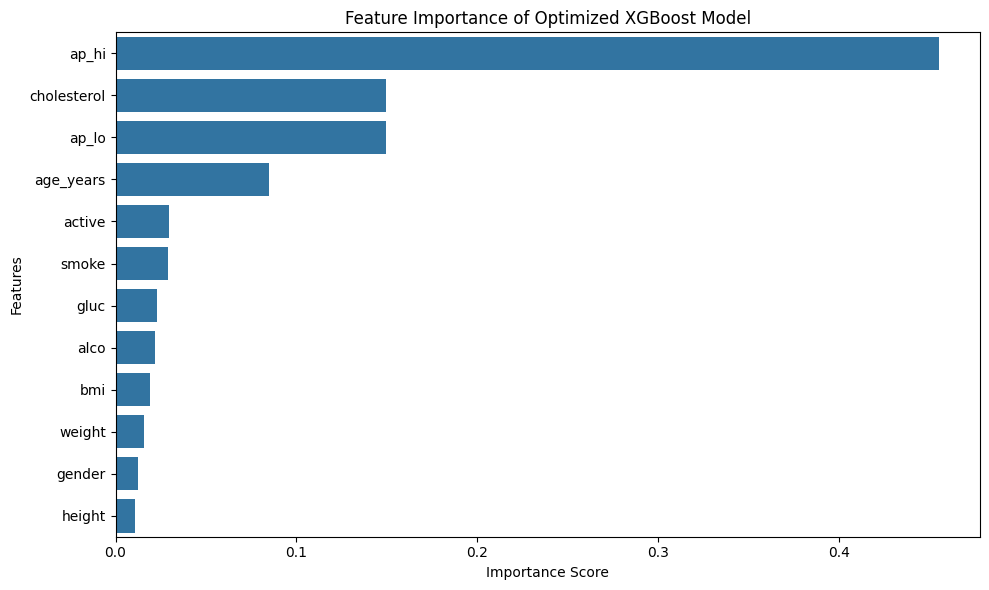

In [12]:
# Create feature importance visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance of Optimized XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/optimized_xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 6.17 – Interpretation

### Observation

The feature importance visualization clearly demonstrates that **systolic blood pressure (`ap_hi`)** is the most significant predictor of heart disease, with a substantially higher importance score than all other features.

**Cholesterol (`cholesterol`)** and **diastolic blood pressure (`ap_lo`)** are the next most influential variables, followed by **age (`age_years`)**. Together, these clinical factors contribute the majority of the model's predictive capability.

Lifestyle-related attributes such as **physical activity**, **smoking**, **glucose level**, and **alcohol consumption** have a moderate influence, while **BMI**, **weight**, **gender**, and **height** contribute comparatively less to the prediction.

The visualization supports both the exploratory data analysis and the feature importance values, confirming that blood pressure, cholesterol, and age are the primary determinants of heart disease risk in the optimized XGBoost model.

## Step 6.18 – Heart Disease Risk Score Generation

### Objective

Generate a heart disease risk score for each patient using the optimized XGBoost model. The risk score represents the predicted probability of heart disease and provides a quantitative measure of an individual's cardiovascular risk.

In [13]:
# Generate heart disease risk scores

risk_probabilities = optimized_xgboost.predict_proba(X_test)[:, 1]

risk_assessment = X_test.copy()

risk_assessment["Actual_Label"] = y_test.values
risk_assessment["Risk_Score"] = risk_probabilities.round(4)

risk_assessment.head(10)

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,Actual_Label,Risk_Score
0,1,158,63.0,110,70,1,1,0,0,0,51,25.236340,1,0.2153
1,1,153,82.0,150,90,1,2,1,0,0,63,35.029262,1,0.8682
2,1,163,88.0,150,90,1,3,0,0,1,59,33.121307,1,0.7900
3,1,169,78.0,140,90,1,1,0,0,1,61,27.309968,1,0.8404
4,1,145,75.0,170,80,3,1,0,0,1,61,35.671819,0,0.7759
5,1,156,87.0,130,80,1,1,0,0,1,55,35.749507,0,0.5290
6,2,180,92.0,120,80,3,1,0,0,1,53,28.395062,1,0.8096
7,2,162,60.0,120,80,1,1,0,0,0,48,22.862369,0,0.3256
8,1,168,67.0,120,80,1,1,0,0,1,54,23.738662,0,0.3556
9,1,168,58.0,90,60,1,1,0,0,1,39,20.549887,0,0.0371


## Step 6.19 – Interpretation

### Observation

The generated Heart Disease Risk Scores demonstrate the optimized XGBoost model's ability to estimate the probability of heart disease for each individual rather than simply predicting whether the disease is present or absent.

Patients with higher risk scores (closer to **1**) are more likely to have heart disease, whereas patients with lower scores (closer to **0**) have a lower predicted risk. The sample output shows a wide range of probabilities, indicating that the model effectively differentiates between low-risk and high-risk individuals.

This probability-based approach makes the prediction results more informative and practical for clinical decision-making, as healthcare professionals can prioritize patients with higher risk scores for further medical evaluation and preventive interventions.

## Step 6.20 – Heart Disease Risk Categorization

### Objective

Categorize patients into Low, Moderate, and High Heart Disease Risk groups based on their predicted risk scores. This categorization improves the interpretability of the model's predictions and makes the results more meaningful for healthcare professionals and end users.

In [14]:
# Define a function to categorize risk levels

def categorize_risk(score):
    if score < 0.30:
        return "Low Risk"
    elif score < 0.70:
        return "Moderate Risk"
    else:
        return "High Risk"

# Apply the function to create a new Risk Category column

risk_assessment["Risk_Category"] = risk_assessment["Risk_Score"].apply(categorize_risk)

# Display the first 10 records

risk_assessment.head(10)

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,Actual_Label,Risk_Score,Risk_Category
0,1,158,63.0,110,70,1,1,0,0,0,51,25.236340,1,0.2153,Low Risk
1,1,153,82.0,150,90,1,2,1,0,0,63,35.029262,1,0.8682,High Risk
2,1,163,88.0,150,90,1,3,0,0,1,59,33.121307,1,0.7900,High Risk
3,1,169,78.0,140,90,1,1,0,0,1,61,27.309968,1,0.8404,High Risk
4,1,145,75.0,170,80,3,1,0,0,1,61,35.671819,0,0.7759,High Risk
5,1,156,87.0,130,80,1,1,0,0,1,55,35.749507,0,0.5290,Moderate Risk
6,2,180,92.0,120,80,3,1,0,0,1,53,28.395062,1,0.8096,High Risk
7,2,162,60.0,120,80,1,1,0,0,0,48,22.862369,0,0.3256,Moderate Risk
8,1,168,67.0,120,80,1,1,0,0,1,54,23.738662,0,0.3556,Moderate Risk
9,1,168,58.0,90,60,1,1,0,0,1,39,20.549887,0,0.0371,Low Risk


## Step 6.21 – Interpretation

### Observation

The generated risk categories successfully classify patients into **Low Risk**, **Moderate Risk**, and **High Risk** groups based on their predicted Heart Disease Risk Scores.

Patients with **High Risk** scores generally exhibit a greater likelihood of developing heart disease, whereas patients classified as **Low Risk** have a much lower predicted probability. Individuals falling under the **Moderate Risk** category represent cases that may require additional clinical evaluation and lifestyle monitoring.

The risk categorization enhances the interpretability of the optimized XGBoost model by transforming probability values into meaningful clinical groups. This makes the prediction results easier to understand for healthcare professionals and improves the usability of the model in real-world heart disease risk assessment applications.

## Step 6.22 – Distribution of Heart Disease Risk Categories

### Objective

Visualize the distribution of patients across the generated Heart Disease Risk Categories. This visualization provides an overview of how the optimized model classifies individuals into Low, Moderate, and High Risk groups.

In [15]:
# Count patients in each risk category

risk_distribution = (
    risk_assessment["Risk_Category"]
    .value_counts()
    .reset_index()
)

risk_distribution.columns = ["Risk Category", "Count"]

risk_distribution

,Risk Category,Count
0,Moderate Risk,5204
1,High Risk,4200
2,Low Risk,3581


## Step 6.23 – Interpretation

### Observation

The risk category distribution indicates that the majority of patients in the testing dataset are classified as **Moderate Risk (5,204 patients)**, followed by **High Risk (4,200 patients)** and **Low Risk (3,581 patients)**.

This distribution suggests that the optimized XGBoost model identifies a considerable proportion of individuals as having moderate to high cardiovascular risk, emphasizing the importance of continuous health monitoring and preventive interventions. The presence of all three risk categories also demonstrates that the model effectively differentiates patients based on their predicted probability of heart disease, making the generated risk assessment more informative than a simple binary classification.

## Step 6.24 – Risk Category Distribution Visualization

### Objective

Visualize the distribution of patients across the generated Heart Disease Risk Categories using a bar chart. This visualization provides an intuitive representation of the number of individuals classified as Low Risk, Moderate Risk, and High Risk by the optimized XGBoost model.

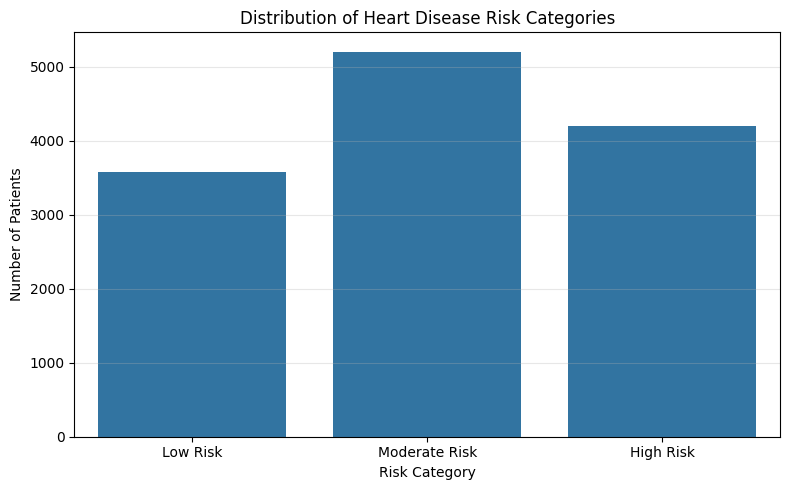

In [16]:
# Visualize the distribution of Heart Disease Risk Categories

plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_distribution,
    x="Risk Category",
    y="Count",
    order=["Low Risk", "Moderate Risk", "High Risk"]
)

plt.title("Distribution of Heart Disease Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/model_evaluation/risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 6.25 – Interpretation

The bar chart clearly illustrates the distribution of patients across the three heart disease risk categories generated by the optimized XGBoost model. The **Moderate Risk** category contains the highest number of patients (5,204), indicating that a large proportion of individuals have a moderate probability of developing heart disease. This is followed by the **High Risk** category with 4,200 patients, while the **Low Risk** category has the smallest population with 3,581 patients.

The distribution suggests that the dataset contains a considerable number of patients who may require preventive healthcare interventions or closer clinical monitoring. The relatively balanced spread across the three categories also indicates that the risk scoring approach is capable of differentiating patients into meaningful risk levels rather than assigning the majority to a single category. This visualization enhances the interpretability of the optimized model and provides an intuitive summary of the overall cardiovascular risk profile of the test population.

## Step 6.26 – Save Heart Disease Risk Assessment Dataset

### Objective
Save the final heart disease risk assessment dataset containing the predicted risk scores and corresponding risk categories. This dataset will serve as the output of the optimization phase and can be used for deployment, visualization, and testing within the Streamlit application.

In [19]:
# Save the final Heart Disease Risk Assessment dataset

risk_assessment.to_csv(
    "../data/processed/heart_disease_risk_assessment.csv",
    index=False
)

print("Heart disease risk assessment dataset saved successfully.")

Heart disease risk assessment dataset saved successfully.


## Step 6.27 – Interpretation

The Heart Disease Risk Assessment dataset was successfully generated and saved for future use. The dataset contains the original patient features along with the **Actual Label**, **Predicted Risk Score**, and **Risk Category** assigned by the optimized XGBoost model.

Saving this dataset ensures that the optimized predictions can be easily accessed for deployment, visualization, and further analysis. It also serves as the primary input for the Streamlit web application, where users will be able to obtain heart disease risk predictions and corresponding risk levels interactively.

# Phase Summary

In this notebook, the XGBoost model was successfully optimized using **RandomizedSearchCV**, resulting in an improved set of hyperparameters. The optimized model was trained, evaluated, and saved for deployment.

A comparison between the original and optimized XGBoost models showed a slight improvement in predictive performance, particularly in terms of ROC-AUC score. Feature importance analysis identified **Systolic Blood Pressure (ap_hi)**, **Cholesterol**, **Diastolic Blood Pressure (ap_lo)**, and **Age** as the most influential predictors of heart disease.

The optimized model was then used to generate probability-based **Heart Disease Risk Scores**, which were further categorized into **Low Risk**, **Moderate Risk**, and **High Risk** groups. The distribution of these risk categories was analyzed and visualized to better understand the model's predictions.

Finally, the complete Heart Disease Risk Assessment dataset containing the predicted risk scores and risk categories was saved for use in the deployment phase.

**Achievements of Notebook 6:**
- Optimized the XGBoost model using RandomizedSearchCV.
- Trained and saved the optimized XGBoost model.
- Compared the performance of the original and optimized models.
- Analyzed feature importance.
- Generated probability-based Heart Disease Risk Scores.
- Categorized patients into Low, Moderate, and High Risk groups.
- Visualized the distribution of risk categories.
- Saved the final Heart Disease Risk Assessment dataset for deployment.